In [ ]:
import pandas as pd
import numpy as np
import sklearn.preprocessing as skpp

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/Gradua%C3%A7%C3%A3o/dados/mtcars.csv")

<Axes: xlabel='wt', ylabel='mpg'>

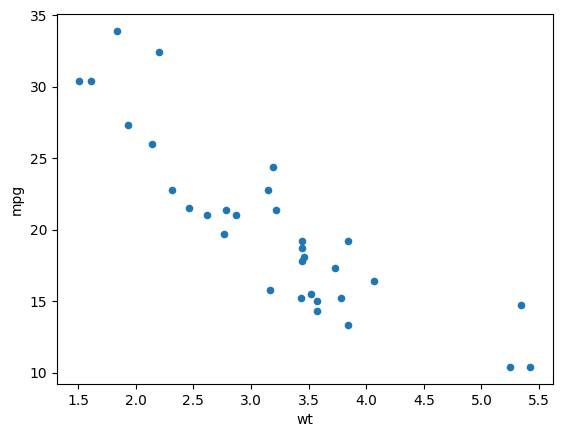

In [ ]:
# Gráfico de dispersão
df.plot.scatter(x="wt", y="mpg")

In [ ]:
df[['wt','mpg']].corr()

,wt,mpg
wt,1.000000,-0.867659
mpg,-0.867659,1.000000


In [ ]:
# Transformação Log-Lin
df['wt_log'] = np.log(df['wt'])
df[['wt_log','mpg']].corr()

,wt_log,mpg
wt_log,1.000000,-0.900081
mpg,-0.900081,1.000000


<Axes: xlabel='wt_log', ylabel='mpg'>

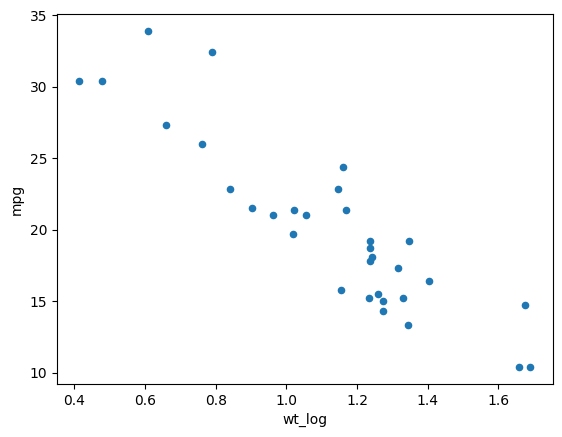

In [ ]:
# Gráfico de dispersão
df.plot.scatter(x="wt_log", y="mpg")

In [ ]:
# Função de transf. polinomial
poly = skpp.PolynomialFeatures(degree=15)

In [ ]:
# Separação de Treino e Teste
# x_treino, x_teste, y_treino, y_teste = train_test_split(df[["wt_log"]], df["mpg"], test_size=0.3, random_state=42)
x_treino, x_teste, y_treino, y_teste = train_test_split(df[["wt"]], df["mpg"], test_size=0.3, random_state=42)

x_treino = poly.fit_transform(x_treino)
x_teste = poly.fit_transform(x_teste)

x_treino

array([[1.00000000e+00, 3.44000000e+00, 1.18336000e+01, 4.07075840e+01,
        1.40034089e+02, 4.81717266e+02, 1.65710740e+03, 5.70044944e+03,
        1.96095461e+04, 6.74568385e+04, 2.32051524e+05, 7.98257244e+05,
        2.74600492e+06, 9.44625692e+06, 3.24951238e+07, 1.11783226e+08],
       [1.00000000e+00, 5.34500000e+00, 2.85690250e+01, 1.52701439e+02,
        8.16189189e+02, 4.36253122e+03, 2.33177294e+04, 1.24633263e+05,
        6.66164793e+05, 3.56065082e+06, 1.90316786e+07, 1.01724322e+08,
        5.43716502e+08, 2.90616471e+09, 1.55334504e+10, 8.30262921e+10],
       [1.00000000e+00, 3.46000000e+00, 1.19716000e+01, 4.14217360e+01,
        1.43319207e+02, 4.95884455e+02, 1.71576021e+03, 5.93653034e+03,
        2.05403950e+04, 7.10697666e+04, 2.45901392e+05, 8.50818818e+05,
        2.94383311e+06, 1.01856626e+07, 3.52423925e+07, 1.21938678e+08],
       [1.00000000e+00, 3.78000000e+00, 1.42884000e+01, 5.40101520e+01,
        2.04158375e+02, 7.71718656e+02, 2.91709652e+03, 1.102

In [ ]:
# Modelo
mod = LinearRegression()
mod.fit(x_treino, y_treino)

# R2
print(mod.score(x_treino, y_treino))

0.9264310264158736


In [ ]:
# Previsão
y_prev = mod.predict(x_teste)
y_prev

array([ 20.93573316, 318.04312426,  13.94059443,  25.49979989,
        20.92868629,  17.19442712,  15.54134338,  31.45812491,
        14.24492857,  20.37350691])

In [ ]:
# Métricas de avaliação de erro de previsão
# 1. MSE - Mean Squared Error. Erro Médio Quadrático
# Erro menor -> melhor
mean_squared_error(y_teste, y_prev)

9475.59261959013

## Redistribuição de Dados

In [ ]:
dfv = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/dados/db_Exercicio_RFM.csv")


,Unnamed: 0,CUSTOMER_ID,STORE_ID,PRODUCT_ID,AMOUNT,DATE
0,1,95595791691,409,196282,8.98,2020-01-01 00:14:41 UTC
1,2,8814812624,62,136956,0.00,2020-01-01 00:10:16 UTC
2,3,38552620634,408,329,9.98,2020-01-01 00:08:29 UTC
3,4,11561694614,405,104089,7.99,2020-01-01 00:06:10 UTC
4,5,1216506698,62,196180,11.96,2020-01-01 00:05:30 UTC
...,...,...,...,...,...,...
92289,92290,10264569679,417,160178,2.15,2019-11-08 10:29:32 UTC
92290,92291,74199480625,405,194991,2.99,2019-11-08 10:29:22 UTC
92291,92292,60400722615,415,185621,4.30,2019-11-08 10:27:06 UTC
92292,92293,3623837660,65,193506,6.29,2019-11-08 10:16:58 UTC


In [ ]:
# Vamos agregar os dados por cliente, para entender comportamente de F (frequência) e V (valor)
dfAgg = dfv.groupby(by=['CUSTOMER_ID'])['AMOUNT'].agg(['sum', 'count'])
dfAgg

,sum,count
CUSTOMER_ID,,
191,17.82,1
1202782,13.80,1
1209604,38.79,1
1480677,8.98,1
1593609,3.99,1
...,...,...
6298976531803343,12.90,1
6298976531895851,89.90,1
6298976532232294,51.78,3


<Axes: xlabel='count', ylabel='sum'>

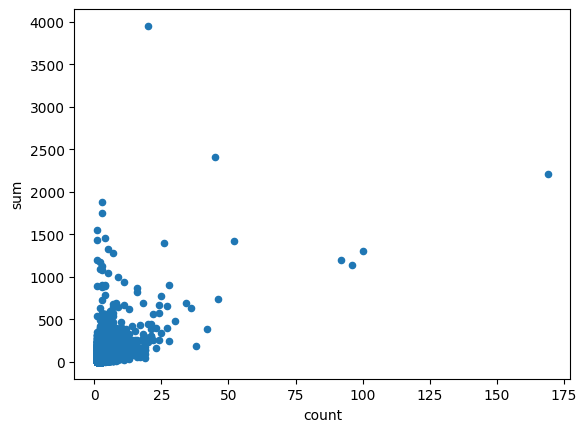

In [ ]:
# Análise de distribuição de F e V
dfAgg.plot.scatter(x="count", y="sum")

array([[<Axes: title={'center': 'sum'}>]], dtype=object)

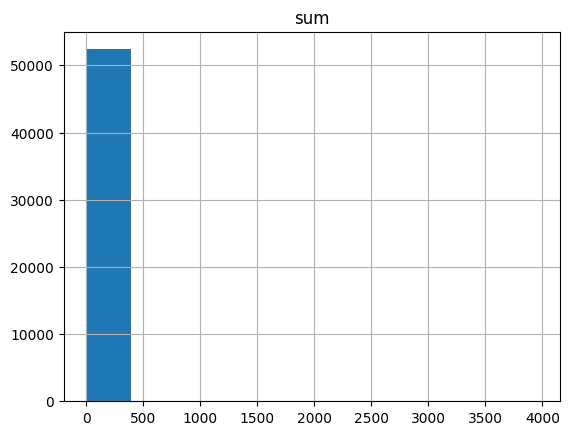

In [ ]:
# Análise de distribuição de cada variável
dfAgg.hist('sum')

array([[<Axes: title={'center': 'count'}>]], dtype=object)

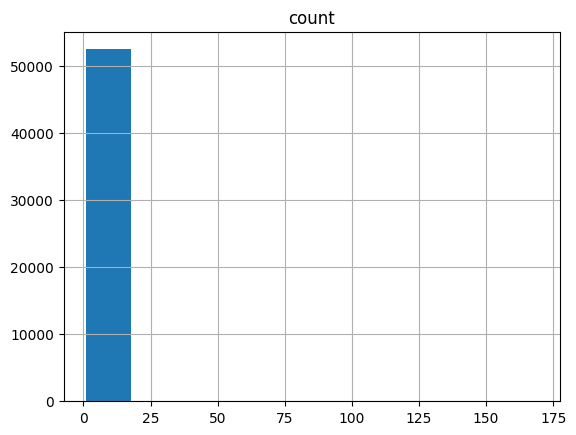

In [ ]:
dfAgg.hist('count')

In [121]:
x = dfAgg['count'].values
y = dfAgg['sum'].values

In [126]:
x_log = np.log(x)
# O log assume como premissa que a variável não pode ser zero. Desta forma, para os valores zerados
# aplicamos um valor ínfimo, que não interfere nos cálculos mas permite a execução do log sem remover estes "clientes"
y[y==0]=0.0001
y_log = np.log(y)

dfAgg['count_log'] = x_log
dfAgg['sum_log'] = y_log

In [127]:
dfAgg

,sum,count,count_log,sum_log
CUSTOMER_ID,,,,
191,17.82,1,0.000000,2.880321
1202782,13.80,1,0.000000,2.624669
1209604,38.79,1,0.000000,3.658162
1480677,8.98,1,0.000000,2.195000
1593609,3.99,1,0.000000,1.383791
...,...,...,...,...
6298976531803343,12.90,1,0.000000,2.557227
6298976531895851,89.90,1,0.000000,4.498698
6298976532232294,51.78,3,1.098612,3.947004


array([[<Axes: title={'center': 'count_log'}>]], dtype=object)

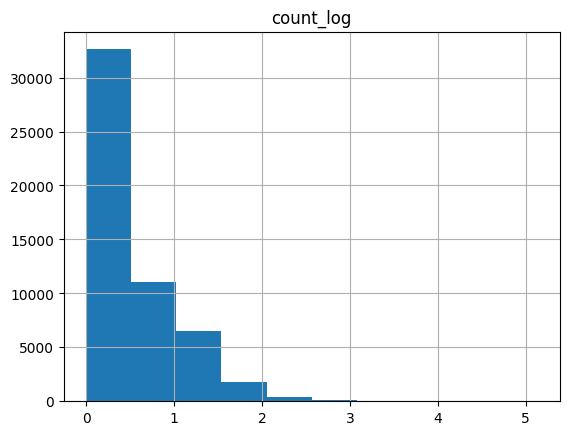

In [128]:
dfAgg.hist('count_log')

array([[<Axes: title={'center': 'sum_log'}>]], dtype=object)

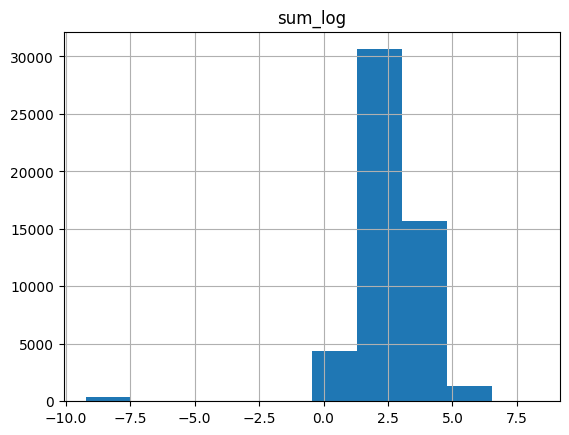

In [129]:
dfAgg.hist('sum_log')

<Axes: xlabel='count_log', ylabel='sum_log'>

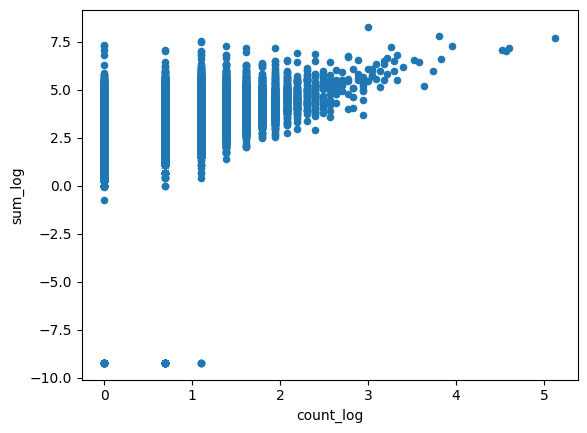

In [130]:
dfAgg.plot.scatter(x="count_log", y="sum_log")